In [ ]:
# 1. Mount Google Drive
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

# 2. Cài đặt thư viện
!pip install faiss-cpu pandas numpy spacy matplotlib seaborn scikit-learn
!python -m spacy download en_core_web_sm

# 3. Import các thư viện cần thiết
import pandas as pd
import numpy as np
import spacy
import re
import faiss
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from spacy.pipeline import EntityRuler

print("\n--- Tất cả thư viện đã sẵn sàng! ---")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 129.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

--- Tất cả thư viện đã sẵn sàng! ---


In [ ]:
import pandas as pd
import numpy as np
import spacy
import re
import faiss
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from spacy.pipeline import EntityRuler
# Đường dẫn file của bạn
file_path = '/content/drive/MyDrive/wikihowAll.csv'

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

try:
    df = pd.read_csv(file_path)

    # Lọc những dòng có headline liên quan đến vật liệu
    keywords = ['material', 'thing', 'need', 'tool', 'equipment', 'ingredient']
    mask = df['headline'].str.contains('|'.join(keywords), case=False, na=False)
    df_filtered = df[mask].copy()

    # Làm sạch nội dung ở cột 'text'
    df_filtered['clean_text'] = df_filtered['text'].apply(clean_text)

    print(f"Đã lọc xong {len(df_filtered)} dòng dữ liệu vật liệu.")
    display(df_filtered[['title', 'headline']].head(3))
except Exception as e:
    print(f"Lỗi: {e}. Hãy kiểm tra lại file tại {file_path}")

Đã lọc xong 45920 dòng dữ liệu vật liệu.


,title,headline
0,How to Be an Organized Artist1,"\nKeep related supplies in the same area.,\nMa..."
1,How to Create a Neopoprealist Art Work,\nCreate a sketch in the NeoPopRealist manner ...
4,How to Be an Organized Artist2,"\nKeep your reference materials, sketches, art..."


In [5]:
!pip install tqdm

from tqdm.auto import tqdm
import spacy
from spacy.pipeline import EntityRuler

# 1. Load model
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer"])

# 2. Cấu hình EntityRuler
if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
    materials_list = [
        "plastic", "bottle", "paper", "cardboard", "glass", "metal", "can", "tin",
        "fabric", "wood", "glue", "tape", "wire", "newspaper", "magazine", "cloth",
        "rubber", "aluminum", "foil", "jar", "container", "box", "cotton", "wool"
    ]
    patterns = [{"label": "MATERIAL", "pattern": [{"LOWER": m}]} for m in materials_list]
    ruler.add_patterns(patterns)

# 3. Hàm xử lý logic
def process_doc(doc):
    # Sử dụng list comprehension để tối ưu tốc độ
    materials = [ent.text for ent in doc.ents if ent.label_ == "MATERIAL"]

    if not materials:
        # Chỉ lấy danh từ, bỏ qua stop words (the, a, an...) để bớt nhiễu
        materials = [token.text for token in doc if token.pos_ == 'NOUN' and not token.is_stop and len(token.text) > 2]

    return " ".join(set(materials))

# 4. Chạy nlp.pipe
print(f"Bắt đầu xử lý {len(df_filtered)} dòng dữ liệu...")

results = []
texts = df_filtered['clean_text'].astype(str).tolist()

for doc in tqdm(nlp.pipe(texts, batch_size=500), total=len(texts)):
    results.append(process_doc(doc))

df_filtered['extracted_materials'] = results

# 5. Hậu xử lý
df_filtered = df_filtered[df_filtered['extracted_materials'] != ""].reset_index(drop=True)
print(f"\nXử lý hoàn tất! Còn lại {len(df_filtered)} dòng.")

Bắt đầu xử lý 45920 dòng dữ liệu...


  0%|          | 0/45920 [00:00<?, ?it/s]


Xử lý hoàn tất! Còn lại 44657 dòng.


In [6]:
# 1. Vectorization với TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_filtered['extracted_materials']).astype('float32')
data_vectors = tfidf_matrix.toarray()
faiss.normalize_L2(data_vectors)

# 2. Xây dựng Index IVFFlat (Phân cụm Voronoi)
dimension = data_vectors.shape[1]
nlist = int(np.sqrt(len(df_filtered))) if len(df_filtered) > 100 else 2
quantizer = faiss.IndexFlatIP(dimension)
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_INNER_PRODUCT)

# Tự động chọn GPU nếu có, không thì dùng CPU
try:
    res = faiss.StandardGpuResources()
    gpu_index = faiss.index_cpu_to_gpu(res, 0, index_ivf)
    print("Train thành công trên GPU!")
except:
    gpu_index = index_ivf
    print("Train thành công trên CPU!")

gpu_index.train(data_vectors)
gpu_index.add(data_vectors)

Train thành công trên CPU!


In [7]:
def suggest_recycling(input_list, top_k=5):
    # Tiền xử lý input
    query_text = " ".join(input_list)
    query_clean = extract_materials(clean_text(query_text))

    # Vectorize
    query_vec = vectorizer.transform([query_clean]).toarray().astype('float32')
    faiss.normalize_L2(query_vec)

    # Tìm kiếm (Lấy top_k * 2 để rerank)
    distances, indices = gpu_index.search(query_vec, top_k * 2)
    results = df_filtered.iloc[indices[0]].copy()
    results['score'] = distances[0]

    # Post-processing: Boosting điểm cho các bài có title "Tái chế"
    boost_keywords = ['recycle', 'reuse', 'upcycle', 'diy', 'craft', 'make']
    def apply_boost(row):
        score = row['score']
        if any(word in str(row['title']).lower() for word in boost_keywords):
            return score * 1.2 # Tăng 20% ưu tiên
        return score

    results['final_score'] = results.apply(apply_boost, axis=1)
    return results.sort_values('final_score', ascending=False).head(top_k)

# THỬ NGHIỆM TẠI ĐÂY
test_input = ["plastic bottle", "paper", "glue"]
recommendations = suggest_recycling(test_input)

print("\n--- KẾT QUẢ GỢI Ý ---")
display(recommendations[['title', 'headline', 'final_score']])


--- KẾT QUẢ GỢI Ý ---


,title,headline,final_score
20726,How to Make Icicle Ornaments2,"\nClean the bottle and remove the label.,\nCut...",1.200000
41215,How to Make a Pincushion Ring from a Plastic B...,"\nMake two holes with a push pin as shown.,\n\...",1.098422
9645,How to Make Stim Toys6,"\nGather your supplies.,\nPour the materials i...",1.098422
37662,How to Make a Bottle Launcher1,\nCollect the materials and building supplies....,1.098422
37377,How to Make a Water Gun2,"\nGather your materials.,\nMake the base.,\nMe...",1.098422


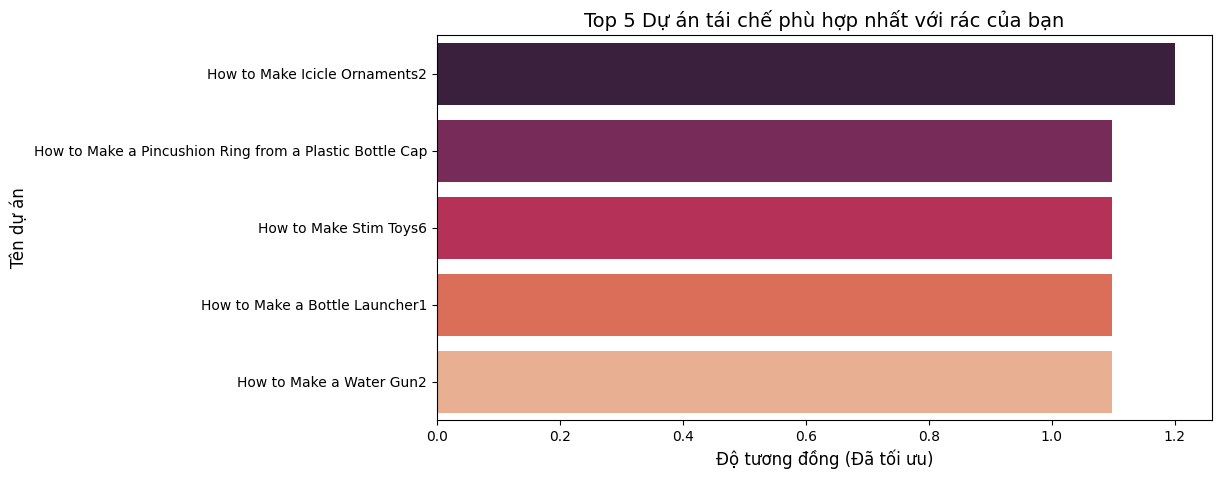

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=recommendations, x='final_score', y='title', hue='title', palette='rocket')
plt.title('Top 5 Dự án tái chế phù hợp nhất với rác của bạn', fontsize=14)
plt.xlabel('Độ tương đồng (Đã tối ưu)', fontsize=12)
plt.ylabel('Tên dự án', fontsize=12)
plt.show()

In [11]:
import os
import pickle
import faiss

# 1. Cấu hình đường dẫn
save_path = '/content/drive/MyDrive/recycling_model/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. Xử lý Index trước khi lưu
if hasattr(faiss, 'index_gpu_to_cpu'):
    try:
        final_index = faiss.index_gpu_to_cpu(gpu_index)
        print("Đã chuyển đổi Index từ GPU sang CPU để lưu trữ.")
    except:
        final_index = gpu_index
else:
    final_index = gpu_index
    print("Đang sử dụng faiss-cpu, chuẩn bị lưu trực tiếp.")

# 3. Ghi file Index
faiss.write_index(final_index, os.path.join(save_path, 'faiss_index.bin'))

# 4. Lưu Vectorizer (TF-IDF)
with open(os.path.join(save_path, 'vectorizer.pkl'), 'wb') as f:
    pickle.dump(vectorizer, f)

# 5. Lưu Data (DataFrame) dưới dạng Pickle để giữ nguyên cấu trúc
df_filtered.to_pickle(os.path.join(save_path, 'processed_data.pkl'))

print(f"\nTHÀNH CÔNG: Toàn bộ model đã được lưu tại: {save_path}")
print("Các file đã lưu: faiss_index.bin, vectorizer.pkl, processed_data.pkl")

Đang sử dụng faiss-cpu, chuẩn bị lưu trực tiếp.

THÀNH CÔNG: Toàn bộ model đã được lưu tại: /content/drive/MyDrive/recycling_model/
Các file đã lưu: faiss_index.bin, vectorizer.pkl, processed_data.pkl


In [12]:
save_path = '/content/drive/MyDrive/recycling_model/'

# Load tất cả
with open(os.path.join(save_path, 'vectorizer.pkl'), 'rb') as f:
    vectorizer = pickle.load(f)
df_filtered = pd.read_pickle(os.path.join(save_path, 'processed_data.pkl'))
gpu_index = faiss.read_index(os.path.join(save_path, 'faiss_index.bin'))

print("--- Model đã được nạp từ Drive! Sẵn sàng sử dụng. ---")

--- Model đã được nạp từ Drive! Sẵn sàng sử dụng. ---


In [14]:
import pandas as pd
import numpy as np
import faiss
import re

def run_inference_test(input_materials, top_k=5):
    """
    Hàm thực hiện dự báo từ danh sách vật liệu đầu vào.
    """
    # 1. Kiểm tra xem các biến model đã được load chưa
    if 'gpu_index' not in globals() or 'vectorizer' not in globals() or 'df_filtered' not in globals():
        print("❌ LỖI: Model chưa được load. Hãy chạy Cell 8 (Load Model) trước.")
        return None

    # 2. Tiền xử lý Input
    raw_input = " ".join(input_materials)

    # Sử dụng hàm extract_materials đã định nghĩa
    input_cleaned = clean_text(raw_input)
    input_extracted = extract_materials(input_cleaned)

    if not input_extracted:
        print("⚠️ Cảnh báo: Không nhận diện được vật liệu nào từ input. Đang dùng text thô.")
        input_extracted = input_cleaned

    # 3. Vectorize & Chuẩn hóa
    query_vec = vectorizer.transform([input_extracted]).toarray().astype('float32')
    faiss.normalize_L2(query_vec)

    # 4. Tìm kiếm bằng FAISS
    distances, indices = gpu_index.search(query_vec, top_k * 2)

    # 5. Lọc kết quả và Boosting
    results = df_filtered.iloc[indices[0]].copy()
    results['raw_score'] = distances[0]

    # Boosting: Ưu tiên các dự án có tính chất "tái chế" rõ rệt
    boost_keywords = ['recycle', 'reuse', 'upcycle', 'diy', 'craft', 'homemade', 'make']
    def calculate_final_score(row):
        score = row['raw_score']
        title_lower = str(row['title']).lower()
        if any(word in title_lower for word in boost_keywords):
            return score * 1.25 # Thưởng 25% điểm cho tiêu đề phù hợp
        return score

    results['final_score'] = results.apply(calculate_final_score, axis=1)

    # Sắp xếp và lấy Top_k
    final_output = results.sort_values('final_score', ascending=False).head(top_k)

    return final_output[['title', 'headline', 'final_score']]

# --- KHU VỰC NHẬP DỮ LIỆU TEST ---
my_trash = ["plastic bottle", "old newspaper", "glue", "scissors"]

print(f"Đang tìm kiếm công thức cho: {', '.join(my_trash)}...")
print("-" * 50)

test_results = run_inference_test(my_trash)

if test_results is not None:
    if len(test_results) > 0:
        print("ĐÃ TÌM THẤY CÁC GỢI Ý PHÙ HỢP:")
        display(test_results)
    else:
        print("Không tìm thấy kết quả nào thực sự phù hợp.")

Đang tìm kiếm công thức cho: plastic bottle, old newspaper, glue, scissors...
--------------------------------------------------
ĐÃ TÌM THẤY CÁC GỢI Ý PHÙ HỢP:


,title,headline,final_score
41215,How to Make a Pincushion Ring from a Plastic B...,"\nMake two holes with a push pin as shown.,\n\...",1.024929
37662,How to Make a Bottle Launcher1,\nCollect the materials and building supplies....,1.024929
37377,How to Make a Water Gun2,"\nGather your materials.,\nMake the base.,\nMe...",1.024929
37369,How to Make a Grenade Launcher2,"\nGather materials.,\nSuperglue the spring to ...",1.024929
9645,How to Make Stim Toys6,"\nGather your supplies.,\nPour the materials i...",1.024929
